In [3]:
# MODULE 1: DATA AUDIT & CLEANING

# IMPORT LIBRARIES

import pandas as pd
import numpy as np


# LOAD CSV FILES

customers = pd.read_csv("Capstone2_Customers.csv")

orders = pd.read_csv("Capstone2_Orders.csv")


print("Libraries imported successfully.")


print("\nDATA LOADED")

print("\nCustomers data loaded successfully.")
print("Orders data loaded successfully.")



# 1. CHECK DATA SHAPE

print("\nCUSTOMERS SHAPE:")
print(customers.shape)

print("\nORDERS SHAPE:")
print(orders.shape)


# 2. CHECK ORIGINAL DATA

print("\nORIGINAL DATA CHECK")

print("Customer rows:", len(customers))
print("Unique CustomerIDs:",
    customers["CustomerID"].nunique()
)

print("Order rows:", len(orders))
print("Unique OrderIDs:",
    orders["OrderID"].nunique()
)

# 3.Check the Data Type

print("\nCustomers data types:")
print(customers.dtypes)

print("\nOrders data types:")
print(orders.dtypes)

# 4.Missing Value Audit

print("\nCustomers missing values:")
print(customers.isnull().sum())

print("\nOrders missing values:")
print(orders.isnull().sum())


#5. Count Duplicate Rows

print("\nCustomers duplicate rows:")
print(customers.duplicated().sum())

print("\nOrders duplicate rows:")
print(orders.duplicated().sum())

# 6.Find the Unique Values for text columns

# For Customers text columns

customer_text_columns = customers.select_dtypes(include="object").columns

print("Customer text columns:")
print(customer_text_columns)

for column in customer_text_columns:
    print("\n", column)
    print(customers[column].unique())

# For Orders text columns

order_text_columns = orders.select_dtypes(include="object").columns

print("\nOrder text columns:")
print(order_text_columns)

for column in order_text_columns:
    print("\n", column)
    print(orders[column].unique())

Libraries imported successfully.

DATA LOADED

Customers data loaded successfully.
Orders data loaded successfully.

CUSTOMERS SHAPE:
(601, 8)

ORDERS SHAPE:
(5005, 11)

ORIGINAL DATA CHECK
Customer rows: 601
Unique CustomerIDs: 600
Order rows: 5005
Unique OrderIDs: 5000

Customers data types:
CustomerID      object
CustomerName    object
Segment         object
Region          object
City            object
State           object
SignupDate      object
AgeGroup        object
dtype: object

Orders data types:
OrderID             object
OrderDate           object
CustomerID          object
ProductCategory     object
Product             object
Quantity           float64
Discount           float64
Sales              float64
Profit             float64
PaymentMethod       object
OrderStatus         object
dtype: object

Customers missing values:
CustomerID      0
CustomerName    0
Segment         1
Region          1
City            0
State           0
SignupDate      0
AgeGroup        0
dtype

In [ ]:
# 4. DATA CLEANING LOG


cleaning_log = []


def add_log(issue, rows_affected, action, why):

    cleaning_log.append({

        "Issue": issue,
        "Rows Affected": rows_affected,
        "Action Taken": action,
        "Why": why

    })

In [4]:
# 2. DATA CLEANING Customers

# REMOVE DUPLICATE ROWS

customers = customers.drop_duplicates()


# Count duplicates BEFORE cleaning
duplicate_customers = customers.duplicated().sum()

print("Duplicate customer rows after cleaning:",
      customers.duplicated().sum())


# STANDARDIZE CUSTOMER ID


customers["CustomerID"] = (
    customers["CustomerID"]
    .astype("string")
    .str.strip()
    .str.upper()
)


# Standardize Customer name

customers["CustomerName"] = (
    customers["CustomerName"]
    .astype("string")
    .str.strip()
    .str.title()
)

# Standardize Region text
customers["Region"] = customers["Region"].astype("string").str.strip().str.title()

# Count missing Region BEFORE cleaning
missing_region = customers["Region"].isnull().sum()

# Fill missing Region values with "Unknown"
customers["Region"] = customers["Region"].fillna("Unknown")



# Standardize Segment text
customers["Segment"] = customers["Segment"].astype("string").str.strip().str.title()

# Count missing Segment BEFORE cleaning
missing_segment = customers["Segment"].isnull().sum()

# Fill missing Segment values with "Unknown"
customers["Segment"] = customers["Segment"].fillna("Unknown")



# STANDARDIZE CITY

customers["City"] = customers["City"].astype("string").str.strip().str.title()

# STANDARDIZE STATE

customers["State"] = customers["State"].astype("string").str.strip().str.title()


# STANDARDIZE AGE GROUP

customers["AgeGroup"] = customers["AgeGroup"].astype("string").str.strip()


# VERIFY CLEANED VALUES

print("\nUNIQUE CUSTOMER NAMES:")
print(customers["CustomerName"].unique())

print("\nUNIQUE REGIONS:")
print(customers["Region"].unique())

print("\nUNIQUE SEGMENTS:")
print(customers["Segment"].unique())

print("\nUNIQUE CITIES:")
print(customers["City"].unique())

print("\nUNIQUE STATES:")
print(customers["State"].unique())

print("\nUNIQUE AGE GROPUS:")
print(customers["AgeGroup"].unique())

# FINAL MISSING VALUE CHECK


print("\nMissing values after cleaning:")
print(customers.isnull().sum())

Duplicate customer rows after cleaning: 0

UNIQUE CUSTOMER NAMES:
<StringArray>
[     'Sanjay Rao',     'Varun Reddy',    'Sanjay Mehta', 'Vikram Kulkarni',
  'Rahul Kulkarni',     'Sneha Joshi',     'Harini Khan',    'Vikram Menon',
    'Sanjay Gupta',    'Karthik Bose',
 ...
     'Arjun Menon',    'Vikram Mehta',  'Manoj Kulkarni',   'Aditya Pillai',
     'Manoj Reddy',    'Aditya Naidu',    'Shreya Menon',    'Sanjay Patel',
  'Priya Kulkarni',     'Nisha Menon']
Length: 330, dtype: string

UNIQUE REGIONS:
<StringArray>
['North', 'West', 'South', 'East', 'Unknown']
Length: 5, dtype: string

UNIQUE SEGMENTS:
<StringArray>
['Consumer', 'Home Office', 'Corporate', 'Unknown']
Length: 4, dtype: string

UNIQUE CITIES:
<StringArray>
[     'Jaipur',       'Surat',   'Ahmedabad',        'Pune',      'Mumbai',
   'Bengaluru',    'Guwahati',     'Chennai',  'Chandigarh',  'Coimbatore',
   'Hyderabad',     'Lucknow',     'Kolkata',       'Delhi',       'Patna',
 'Bhubaneswar']
Length: 16, dtype

In [11]:
# Cleaning Orders

print("\nORDERS DATA CLEANING")

# Create a copy to preserve original data

orders= orders.copy()

print("\nOrders shape:", orders.shape)

# Remove Duplicate Orders

order_duplicates = orders.duplicated().sum()

print("Duplicate order rows before cleaning:",
      order_duplicates)

orders = orders.drop_duplicates()

print("Duplicate order rows after cleaning:",
    orders.duplicated().sum()
)

# CLEAN SALES COLUMN

# Missing Sales

#Convert Sales to numeric first

orders["Sales"] = pd.to_numeric(
orders["Sales"],
errors="coerce"
)

# Count missing Sales BEFORE cleaning

missing_sales = orders["Sales"].isnull().sum()

print(
    "\nMissing Sales before cleaning:",
    missing_sales
)


#Remove rows where Sales is missing

orders = orders.dropna(
subset=["Sales"]
).copy()

print(
"Missing Sales after cleaning:",
orders["Sales"].isnull().sum()
)

# CLEAN PROFIT COLUMN

# Missing Profit

#Convert Profit to numeric first

orders["Profit"] = pd.to_numeric(
orders["Profit"],
errors="coerce"
)

# Count missing Profit BEFORE cleaning

missing_profit = orders["Profit"].isnull().sum()

print(
    "\nMissing Profit before cleaning:",
    missing_profit
)


#Remove rows where Profit is missing

orders= orders.dropna(
subset=["Profit"]
).copy()

print(
"Missing Profit after cleaning:",
orders["Profit"].isnull().sum()
)



# Standardize Product Category

# Count missing BEFORE cleaning


missing_product_category = (
    orders["ProductCategory"].isnull().sum()
)


orders["ProductCategory"] = (
    orders["ProductCategory"]
    .astype("string")
    .str.strip()
    .str.title()
)

print(orders["ProductCategory"].unique())


print("\nPRODUCT CATEGORY VALUES:")
print(
    orders["ProductCategory"]
    .value_counts(dropna=False)
)

# Fill missing Productcategory values with "Unknown"

orders["ProductCategory"] = orders["ProductCategory"].fillna("Unknown")


# Standardize Product

# Count missing Product BEFORE cleaning

missing_product = orders["Product"].isnull().sum()

print(
    "\nMissing Product before cleaning:",
    missing_product
)

orders["Product"] = orders["Product"].astype("string").str.strip().str.title()

print(orders["Product"].unique())

print (orders["Product"]
    .value_counts(dropna=False)
)


# Fill missing Product values with "Unknown"

orders["Product"] = orders["Product"].fillna("Unknown")


# Standardize Quantity
# CLEAN QUANTITY


# Convert Quantity to numeric

orders["Quantity"] = pd.to_numeric(
    orders["Quantity"],
    errors="coerce"
)


# Count missing BEFORE cleaning

missing_quantity = (
    orders["Quantity"].isnull().sum()
)


print(
    "\nMissing Quantity before cleaning:",
    missing_quantity
)


# Fill missing Quantity with median

quantity_median = orders["Quantity"].median()

orders["Quantity"] = (
    orders["Quantity"]
    .fillna(quantity_median)
)


print(
    "Missing Quantity after cleaning:",
    orders["Quantity"].isnull().sum()
)

print(orders["Quantity"].unique())

print("\nQuantity VALUES:")

print (orders["Quantity"]
    .value_counts(dropna=False)
)


# Standardize Discount


# Convert Discount to numeric

orders["Discount"] = pd.to_numeric(
    orders["Discount"],
    errors="coerce"
)


# Count missing BEFORE cleaning

missing_discount = (
    orders["Discount"].isnull().sum()
)


print(
    "\nMissing Discount before cleaning:",
    missing_discount
)


# Fill missing Discount with 0

orders["Discount"] = (
    orders["Discount"].fillna(0)
)


print(
    "Missing Discount after cleaning:",
    orders["Discount"].isnull().sum()
)



# Standardize PaymentMethod

# Count missing BEFORE cleaning

missing_payment_method = (
    orders["PaymentMethod"].isnull().sum()
)

orders["PaymentMethod"] = orders["PaymentMethod"].astype("string").str.strip().str.title()

print(orders["PaymentMethod"].unique())

print("\nPAYMENT METHOD VALUES:")

print (orders["PaymentMethod"]
    .value_counts(dropna=False))

# Fill missing PaymentMethod values with "Unknown"

orders["PaymentMethod"] = orders["PaymentMethod"].fillna("Unknown")


# CLEAN ORDER STATUS


# Count missing OrderStatus BEFORE cleaning

missing_order_status = (orders["OrderStatus"].isnull().sum())

print(
    "\nMissing OrderStatus before cleaning:",
    missing_order_status
)

 # Standardize OrderStatus

orders["OrderStatus"] = orders["OrderStatus"].astype("string").str.strip().str.title()

print(orders["OrderStatus"].unique())

print (orders["OrderStatus"]
    .value_counts(dropna=False))


print(
    "\nMissing OrderStatus after cleaning:",
    orders["OrderStatus"].isnull().sum()
)


# Fill missing OrderStatus values with "Unknown"

orders["OrderStatus"] = orders["OrderStatus"].fillna("Unknown")


# Standardize OrderID

# Count missing BEFORE cleaning

missing_order_id = (
    orders["OrderID"].isnull().sum()
)

orders["OrderID"] = orders["OrderID"].astype("string").str.strip().str.upper()

print(orders["OrderID"].unique())

print("\nORDER ID VALUES:")

print (orders["OrderID"]
    .value_counts(dropna=False))


print(
    "\nMissing OrderID:",
    missing_order_id
)



 # Standardize CustomerID

# Check missing CustomerIDs

missing_customer_id = (
    orders["CustomerID"].isnull().sum()
)

print(
    "\nMissing CustomerID:",
    missing_customer_id
)


orders["CustomerID"] = orders["CustomerID"].astype("string").str.strip().str.upper()

print(orders["CustomerID"].unique())

print (orders["CustomerID"]
    .value_counts(dropna=False))




# FINAL MISSING VALUE CHECK - ORDERS


print("\nMISSING VALUES AFTER CLEANING ORDERS:")

print(
    orders.isnull().sum()
)


ORDERS DATA CLEANING

Orders shape: (4991, 11)
Duplicate order rows before cleaning: 0
Duplicate order rows after cleaning: 0

Missing Sales before cleaning: 0
Missing Sales after cleaning: 0

Missing Profit before cleaning: 0
Missing Profit after cleaning: 0
<StringArray>
['Office Supplies', 'Accessories', 'Furniture', 'Electronics', 'Unknown']
Length: 5, dtype: string

PRODUCT CATEGORY VALUES:
ProductCategory
Electronics        1575
Office Supplies    1306
Furniture          1202
Accessories         907
Unknown               1
Name: count, dtype: Int64

Missing Product before cleaning: 0
<StringArray>
[       'Printer',        'Usb Hub',        'Cabinet',           'Desk',
        'Monitor',      'Bookshelf',        'Stapler', 'Desk Organizer',
     'Headphones',   'Office Chair',         'Laptop',       'Keyboard',
          'Mouse',         'Webcam',          'Paper',       'Backpack',
        'Unknown']
Length: 17, dtype: string
Product
Monitor           405
Headphones        397

In [12]:
#3. REFERENTIAL INTEGRITY CHECK

print("\nREFERENTIAL INTEGRITY CHECK")

# Find orders with CustomerIDs not present in customers

invalid_orders = orders[
    ~orders["CustomerID"].isin(customers["CustomerID"])
]
invalid_order_count = len(invalid_orders)

print("\nNumber of invalid orders before cleaning:")
print(invalid_order_count)

print("\nOrders with invalid CustomerIDs:")
print(invalid_orders)


# REMOVE ORDERS WITH INVALID CUSTOMER IDs


orders = orders[
    orders["CustomerID"].isin(customers["CustomerID"])
].copy()


print("\nInvalid orders removed.")


# VERIFY REFERENTIAL INTEGRITY AGAIN


remaining_invalid_orders = orders[
    ~orders["CustomerID"].isin(customers["CustomerID"])
]


print("\nNumber of invalid orders after cleaning:")
print(len(remaining_invalid_orders))



REFERENTIAL INTEGRITY CHECK

Number of invalid orders before cleaning:
0

Orders with invalid CustomerIDs:
Empty DataFrame
Columns: [OrderID, OrderDate, CustomerID, ProductCategory, Product, Quantity, Discount, Sales, Profit, PaymentMethod, OrderStatus]
Index: []

Invalid orders removed.

Number of invalid orders after cleaning:
0


In [13]:

# 5. DATA CLEANING LOG

print("\n" + "=" * 70)
print("DATA CLEANING LOG")
print("=" * 70)


cleaning_log = pd.DataFrame({

    "Issue": [

        "Duplicate customer rows",
        "Missing Region",
        "Missing Segment",
        "Duplicate order rows",
        "Missing Sales",
        "Missing Profit",
        "Missing ProductCategory",
        "Missing Product",
        "Missing Quantity",
        "Missing Discount",
        "Missing PaymentMethod",
        "Missing OrderStatus",
        "Missing OrderID",
        "Missing CustomerID",
        "Invalid CustomerIDs in Orders"

    ],

    "Rows Affected": [

        duplicate_customers,
        missing_region,
        missing_segment,
        order_duplicates,
        missing_sales,
        missing_profit,
        missing_product_category,
        missing_product,
        missing_quantity,
        missing_discount,
        missing_payment_method,
        missing_order_status,
        missing_order_id,
        missing_customer_id,
        invalid_order_count

    ],

    "Action": [

        "Removed duplicate rows",
        "Filled with Unknown",
        "Filled with Unknown",
        "Removed duplicate rows",
        "Removed rows with missing Sales",
        "Removed rows with missing Profit",
        "Filled with Unknown",
        "Filled with Unknown",
        "Filled with median",
        "Filled with 0",
        "Filled with Unknown",
        "Filled with Unknown",
        "Standardized and checked",
        "Standardized and checked",
        "Removed orders with invalid CustomerIDs"

    ],

    "Why": [

        "Duplicate records can affect analysis",
        "Actual Region cannot be reliably determined",
        "Actual Segment cannot be reliably determined",
        "Duplicate orders can cause double-counting",
        "Sales cannot be reliably guessed",
        "Profit cannot be reliably inferred",
        "Product category cannot be reliably determined",
        "Product cannot be reliably determined",
        "Median preserves the numeric data type",
        "Missing discount is treated as no discount",
        "Actual payment method cannot be reliably determined",
        "Actual order status cannot be reliably determined",
        "OrderID is an identifier and should not be replaced",
        "CustomerID is required for customer matching",
        "Every order must match an existing customer"

    ]

})


print(cleaning_log.to_string(index=False))


DATA CLEANING LOG
                        Issue  Rows Affected                                  Action                                                 Why
      Duplicate customer rows              0                  Removed duplicate rows               Duplicate records can affect analysis
               Missing Region              1                     Filled with Unknown         Actual Region cannot be reliably determined
              Missing Segment              1                     Filled with Unknown        Actual Segment cannot be reliably determined
         Duplicate order rows              0                  Removed duplicate rows          Duplicate orders can cause double-counting
                Missing Sales              0         Removed rows with missing Sales                    Sales cannot be reliably guessed
               Missing Profit              0        Removed rows with missing Profit                  Profit cannot be reliably inferred
      Missing ProductC

In [14]:
#RE-RUN THE AUDIT AFTER CLEANING

#This audit checks the cleaned datasets again.

# 6. FINAL DATA QUALITY AUDIT


print("\n" + "=" * 70)
print("FINAL DATA QUALITY AUDIT AFTER CLEANING")
print("=" * 70)


# DATA SHAPE


print("\nCUSTOMERS SHAPE:")
print(customers.shape)

print("\nORDERS SHAPE:")
print(orders.shape)


# DATA TYPES


print("\nCUSTOMERS DATA TYPES:")
print(customers.dtypes)

print("\nORDERS DATA TYPES:")
print(orders.dtypes)


# MISSING VALUES


print("\nCUSTOMERS MISSING VALUES AFTER CLEANING:")
print(customers.isnull().sum())

print("\nORDERS MISSING VALUES AFTER CLEANING:")
print(orders.isnull().sum())


# DUPLICATE ROWS


print("\nCUSTOMERS DUPLICATE ROWS AFTER CLEANING:")
print(customers.duplicated().sum())

print("\nORDERS DUPLICATE ROWS AFTER CLEANING:")
print(orders.duplicated().sum())



# UNIQUE VALUES FOR CUSTOMER TEXT COLUMNS


print("\nCUSTOMERS TEXT COLUMN UNIQUE VALUES:")

customer_text_columns = (
    customers.select_dtypes(include="object").columns
)

for column in customer_text_columns:

    print("\n", column)
    print(customers[column].unique())


# UNIQUE VALUES FOR ORDER TEXT COLUMNS


print("\nORDERS TEXT COLUMN UNIQUE VALUES:")

order_text_columns = (
    orders.select_dtypes(include="object").columns
)

for column in order_text_columns:

    print("\n", column)
    print(orders[column].unique())


FINAL DATA QUALITY AUDIT AFTER CLEANING

CUSTOMERS SHAPE:
(600, 8)

ORDERS SHAPE:
(4991, 11)

CUSTOMERS DATA TYPES:
CustomerID      string[python]
CustomerName    string[python]
Segment         string[python]
Region          string[python]
City            string[python]
State           string[python]
SignupDate              object
AgeGroup        string[python]
dtype: object

ORDERS DATA TYPES:
OrderID            string[python]
OrderDate                  object
CustomerID         string[python]
ProductCategory    string[python]
Product            string[python]
Quantity                  float64
Discount                  float64
Sales                     float64
Profit                    float64
PaymentMethod      string[python]
OrderStatus        string[python]
dtype: object

CUSTOMERS MISSING VALUES AFTER CLEANING:
CustomerID      0
CustomerName    0
Segment         0
Region          0
City            0
State           0
SignupDate      0
AgeGroup        0
dtype: int64

ORDERS MISSIN

In [15]:
# 7. FINAL VALIDATION

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

# CHECK MISSING VALUES


customer_missing_final = (
    customers.isnull().sum().sum()
)

order_missing_final = (
    orders.isnull().sum().sum()
)


# CHECK DUPLICATES


customer_duplicates_final = (
    customers.duplicated().sum()
)

order_duplicates_final = (
    orders.duplicated().sum()
)


# CHECK REFERENTIAL INTEGRITY


referential_mismatches_final = (
    ~orders["CustomerID"]
    .isin(customers["CustomerID"])
).sum()


# PRINT RESULTS


print("\nTotal missing values in Customers:")
print(customer_missing_final)

print("\nTotal missing values in Orders:")
print(order_missing_final)

print("\nDuplicate rows in Customers:")
print(customer_duplicates_final)

print("\nDuplicate rows in Orders:")
print(order_duplicates_final)

print("\nReferential mismatches:")
print(referential_mismatches_final)



# FINAL CONFIRMATION


if (
    customer_missing_final == 0
    and order_missing_final == 0
    and customer_duplicates_final == 0
    and order_duplicates_final == 0
    and referential_mismatches_final == 0
):

    print("\nSUCCESS!")
    print(
        "All identified data quality issues "
        "have been resolved successfully."
    )

else:

    print("\nWARNING!")
    print(
        "Some data quality issues still need "
        "to be reviewed."
    )


FINAL VALIDATION

Total missing values in Customers:
0

Total missing values in Orders:
0

Duplicate rows in Customers:
0

Duplicate rows in Orders:
0

Referential mismatches:
0

SUCCESS!
All identified data quality issues have been resolved successfully.


In [23]:
# MODULE 2: PYTHON & NUMPY FOUNDATIONS

import pandas as pd
import numpy as np


#1. Function for Loading Data + Exception Handling

# FUNCTION 1: LOAD DATA

def load_data(customer_file, order_file):

    try:

        customers = pd.read_csv(customer_file)
        orders = pd.read_csv(order_file)

        print("Files loaded successfully.")

        return customers, orders

    except FileNotFoundError:

        print("Error: One or both files were not found.")

        return None, None

    except pd.errors.EmptyDataError:

        print("Error: One of the files is empty.")

        return None, None

    except pd.errors.ParserError:

        print("Error: One of the files is corrupted or has invalid formatting.")

        return None, None

    except Exception as error:

        print("An unexpected error occurred:", error)

        return None, None


# CALL FUNCTION


customers, orders = load_data(
    "Capstone2_Customers.csv",
    "Capstone2_Orders.csv"
)


 # FUNCTION 2 for Cleaning Data
 # CLEAN CUSTOMERS DATA


def clean_customers(customers):

    # Remove duplicates
    customers = customers.drop_duplicates()

    # Standardize CustomerID
    customers["CustomerID"] = (
        customers["CustomerID"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    # Standardize CustomerName
    customers["CustomerName"] = (
        customers["CustomerName"]
        .astype("string")
        .str.strip()
        .str.title()
    )

    # Clean Region
    customers["Region"] = (
        customers["Region"]
        .astype("string")
        .str.strip()
        .str.title()
        .fillna("Unknown")
    )

    # Clean Segment
    customers["Segment"] = (
        customers["Segment"]
        .astype("string")
        .str.strip()
        .str.title()
        .fillna("Unknown")
    )

    return customers




Files loaded successfully.


In [34]:
#3. Function for Cleaning Orders

# FUNCTION 3: CLEAN ORDERS DATA


def clean_orders(orders):

    # Remove duplicates
    orders = orders.drop_duplicates().copy()


    # Convert Sales to numeric
    orders["Sales"] = pd.to_numeric(
        orders["Sales"],
        errors="coerce"
    )


    # Remove missing Sales
    orders = orders.dropna(
        subset=["Sales"]
    )


    # Convert Profit to numeric
    orders["Profit"] = pd.to_numeric(
        orders["Profit"],
        errors="coerce"
    )


    # Remove missing Profit
    orders = orders.dropna(
        subset=["Profit"]
    )


    # Clean ProductCategory
    orders["ProductCategory"] = (
        orders["ProductCategory"]
        .astype("string")
        .str.strip()
        .str.title()
        .fillna("Unknown")
    )


    # Clean Quantity
    orders["Quantity"] = pd.to_numeric(
        orders["Quantity"],
        errors="coerce"
    )


    # Fill missing Quantity with median
    orders["Quantity"] = (
        orders["Quantity"]
        .fillna(orders["Quantity"].median())
    )


    # Convert Discount to numeric
    orders["Discount"] = pd.to_numeric(
        orders["Discount"],
        errors="coerce"
    )


    # Fill missing Discount with 0
    orders["Discount"] = (
        orders["Discount"]
        .fillna(0)
    )


    return orders

In [35]:
#4. Function for Transforming Data

#A transformation function can create new calculated columns.


# FUNCTION 4: TRANSFORM DATA


def transform_data(orders):

    # Calculate Sales per Unit

    orders["SalesPerUnit"] = (
        orders["Sales"] /
        orders["Quantity"]
    )


    # Calculate Profit Margin

    orders["ProfitMargin"] = np.where(
        orders["Sales"] != 0,
        (orders["Profit"] / orders["Sales"]) * 100,
        0
    )


    return orders

In [36]:
#5. Apply the Functions

# APPLY FUNCTIONS


if customers is not None and orders is not None:

    customers = clean_customers(customers)

    orders = clean_orders(orders)

    orders = transform_data(orders)

    print("\nData cleaning and transformation completed.")


# Mo0dular functions-	load_data(), clean_customers(), clean_orders(), transform_data()
#Exception handling - try/except


Data cleaning and transformation completed.


In [38]:
#6. Convert Pandas Columns to NumPy Arrays

# NUMPY ARRAY OPERATIONS


sales_array = orders["Sales"].to_numpy()

profit_array = orders["Profit"].to_numpy()

quantity_array = orders["Quantity"].to_numpy()

In [41]:
#7. Mean, Standard Deviation, Minimum, and Maximum

# SALES STATISTICS USING NUMPY


print("\nSALES NUMPY STATISTICS")

print("Mean:", np.mean(sales_array))

print("Standard Deviation:", np.std(sales_array))

print("Minimum:", np.min(sales_array))

print("Maximum:", np.max(sales_array))

# PROFIT NUMPY STATISTICS


print("\nPROFIT NUMPY STATISTICS")

print("Mean:", np.mean(profit_array))

print("Standard Deviation:", np.std(profit_array))

print("Minimum:", np.min(profit_array))

print("Maximum:", np.max(profit_array))


SALES NUMPY STATISTICS
Mean: 28872.21594318864
Standard Deviation: 102364.51325904783
Minimum: 245.0
Maximum: 6187500.0

PROFIT NUMPY STATISTICS
Mean: 2436.530696139228
Standard Deviation: 14905.854464608192
Minimum: -479560.98
Maximum: 135000.0


In [42]:
#8. Normalization Using NumPy

# NORMALIZE SALES

sales_normalized = (
    (sales_array - np.min(sales_array)) /
    (np.max(sales_array) - np.min(sales_array))
)


print("\nNORMALIZED SALES:")

print(sales_normalized)

#Add it back to the DataFrame
#orders["NormalizedSales"] = sales_normalized


NORMALIZED SALES:
[0.00640914 0.00134228 0.00332215 ... 0.00737888 0.00022223 0.0006877 ]


In [43]:
#9. Loss Flagging Using np.where()
#A loss occurs when:Profit < 0

# LOSS FLAGGING USING NUMPY


orders["LossFlag"] = np.where(
    orders["Profit"] < 0,
    "Loss",
    "Profit"
)


print("\nLOSS FLAG COUNTS:")

print(
    orders["LossFlag"]
    .value_counts()
)


LOSS FLAG COUNTS:
LossFlag
Profit    4315
Loss       684
Name: count, dtype: int64


In [44]:
# MODULE 3: PANDAS WRANGLING & EDA


import pandas as pd
import numpy as np

# 1. MERGE CUSTOMERS AND ORDERS


# We use an INNER JOIN because we only want orders that have
# a matching CustomerID in the Customers table.
# This avoids including orders belonging to unknown customers.

merged_df = pd.merge(
    orders,
    customers,
    on="CustomerID",
    how="inner"
)

print("\nMERGED DATA")
print(merged_df.head())

print("\nMerged Shape:")
print(merged_df.shape)



MERGED DATA
    OrderID   OrderDate CustomerID  ProductCategory  Product  Quantity  \
0  ORD00001  2025-08-27   CUST0258  Office Supplies  Printer       3.0   
1  ORD00002  2025-12-24   CUST0030      Accessories  USB Hub       5.0   
2  ORD00003  2026-07-15   CUST0333        Furniture  Cabinet       2.0   
3  ORD00004  2026-02-18   CUST0576        Furniture     Desk       1.0   
4  ORD00005  2025-08-21   CUST0212  Office Supplies  Printer       3.0   

   Discount    Sales   Profit     PaymentMethod  ... SalesPerUnit  \
0      0.05  39900.0  7045.57               UPI  ...      13300.0   
1      0.05   8550.0  3043.49  Cash on Delivery  ...       1710.0   
2      0.20  20800.0  3564.27              Card  ...      10400.0   
3      0.05  14250.0  2908.49               UPI  ...      14250.0   
4      0.10  37800.0  5141.35        NetBanking  ...      12600.0   

   ProfitMargin  LossFlag   CustomerName   Segment Region       City  \
0     17.658070    Profit    Priya Naidu  Consumer  Sou

In [47]:
# 2. GROUPBY WITH MULTIPLE AGGREGATIONS

# Business use:
# This helps compare sales and profitability across regions.

region_summary = merged_df.groupby("Region").agg(
    TotalSales=("Sales", "sum"),
    TotalProfit=("Profit", "sum"),
    AverageSales=("Sales", "mean"),
    AverageProfit=("Profit", "mean"),
    TotalQuantity=("Quantity", "sum"),
    OrderCount=("OrderID", "count")
).reset_index()

print("\nREGION SUMMARY ")
print(region_summary)


# 3. PIVOT TABLE

# Pivot table shows Sales by Region and ProductCategory.

sales_pivot = pd.pivot_table(
    merged_df,
    values="Sales",
    index="Region",
    columns="ProductCategory",
    aggfunc="sum",
    fill_value=0
)

print("\n========== SALES PIVOT TABLE ==========")
print(sales_pivot)



# 4. CALCULATED COLUMN: PROFIT MARGIN


merged_df["ProfitMargin"] = np.where(
    merged_df["Sales"] != 0,
    (merged_df["Profit"] / merged_df["Sales"]) * 100,
    0
)


# 5. CALCULATED COLUMN: PROFIT PER UNIT


merged_df["ProfitPerUnit"] = np.where(
    merged_df["Quantity"] != 0,
    merged_df["Profit"] / merged_df["Quantity"],
    0
)

print("\n========== CALCULATED COLUMNS ==========")
print(
    merged_df[
        ["Sales", "Profit", "Quantity",
         "ProfitMargin", "ProfitPerUnit"]
    ].head()
)



REGION SUMMARY 
    Region  TotalSales  TotalProfit  AverageSales  AverageProfit  \
0     East  17772560.0   1523866.79  28481.666667    2442.094215   
1    North  23327180.0   2330015.78  26122.262038    2609.200202   
2    South  77069287.5   5557848.11  30034.796376    2165.957954   
3  Unknown    147810.0     -9053.61  29562.000000   -1810.722000   
4     West  25837615.0   2789688.43  28644.805987    3092.780965   

   TotalQuantity  OrderCount  
0         1804.0         624  
1         2515.0         893  
2         7507.0        2566  
3           18.0           5  
4         2593.0         902  

========== SALES PIVOT TABLE ==========
ProductCategory  Accessories  Electronics   Furniture  Office Supplies  \
Region                                                                   
East                736240.0   10537550.0   4880050.0        1618720.0   
North               841910.0   13821450.0   6335250.0        2328570.0   
South              4046820.0   47604275.0  18671600

In [48]:
# 6. IQR OUTLIER DETECTION


def detect_iqr_outliers(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nIQR OUTLIERS: {column} ")

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

    return outliers


# Detect outliers in Sales
sales_outliers = detect_iqr_outliers(
    merged_df,
    "Sales"
)

# Detect outliers in Profit
profit_outliers = detect_iqr_outliers(
    merged_df,
    "Profit"
)



IQR OUTLIERS: Sales 
Q1: 2700.0
Q3: 32400.0
IQR: 29700.0
Lower Bound: -41850.0
Upper Bound: 76950.0
Number of Outliers: 393

IQR OUTLIERS: Profit 
Q1: 331.04999999999995
Q3: 4800.0
IQR: 4468.95
Lower Bound: -6372.374999999999
Upper Bound: 11503.425
Number of Outliers: 594


In [51]:
# 7. CORRELATION MATRIX


numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "ProfitMargin",
    "ProfitPerUnit"
]

correlation_matrix = merged_df[numeric_columns].corr()

print("\n CORRELATION MATRIX")
print(correlation_matrix.round(2))


# 8. PLAIN-ENGLISH CORRELATION INTERPRETATION


print("\nCORRELATION INTERPRETATION ")

for column1 in correlation_matrix.columns:

    for column2 in correlation_matrix.columns:

        # Avoid duplicate pairs and self-correlation
        if column1 < column2:

            correlation = correlation_matrix.loc[
                column1,
                column2
            ]

            if correlation > 0.3:

                print(
                    f"{column1} and {column2}: "
                    f"Positive correlation ({correlation:.2f}). "
                    f"As {column1} increases, {column2} tends "
                    f"to increase as well."
                )

            elif correlation < -0.3:

                print(
                    f"{column1} and {column2}: "
                    f"Negative correlation ({correlation:.2f}). "
                    f"As {column1} increases, {column2} tends "
                    f"to decrease."
                )


 CORRELATION MATRIX
               Sales  Quantity  Discount  Profit  ProfitMargin  ProfitPerUnit
Sales           1.00      0.75     -0.04   -0.21         -0.01           0.05
Quantity        0.75      1.00     -0.02   -0.15          0.00          -0.02
Discount       -0.04     -0.02      1.00   -0.09         -0.04          -0.14
Profit         -0.21     -0.15     -0.09    1.00          0.11           0.68
ProfitMargin   -0.01      0.00     -0.04    0.11          1.00           0.23
ProfitPerUnit   0.05     -0.02     -0.14    0.68          0.23           1.00

CORRELATION INTERPRETATION 
Quantity and Sales: Positive correlation (0.75). As Quantity increases, Sales tends to increase as well.
Profit and ProfitPerUnit: Positive correlation (0.68). As Profit increases, ProfitPerUnit tends to increase as well.


In [53]:
# MODULE 4: STATISTICS
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

# 1. DESCRIPTIVE STATISTICS


numeric_columns = [
    "Sales",
    "Profit",
    "Quantity",
    "Discount"
]

print("\n========== DESCRIPTIVE STATISTICS ==========")

descriptive_stats = orders[numeric_columns].describe()

print(descriptive_stats)

# Additional statistics
print("\n========== MEAN, MEDIAN AND STD ==========")

for column in numeric_columns:

    print(f"\n{column}")

    print("Mean:", orders[column].mean())
    print("Median:", orders[column].median())
    print("Standard Deviation:", orders[column].std())
    print("Minimum:", orders[column].min())
    print("Maximum:", orders[column].max())


========== DESCRIPTIVE STATISTICS ==========
              Sales         Profit     Quantity     Discount
count  4.999000e+03    4999.000000  4999.000000  4999.000000
mean   2.887222e+04    2436.530696     2.894979     0.091858
std    1.023748e+05   14907.345572     3.186979     0.073006
min    2.450000e+02 -479560.980000     1.000000     0.000000
25%    2.700000e+03     331.390000     1.000000     0.050000
50%    1.080000e+04    1768.370000     2.000000     0.100000
75%    3.240000e+04    4800.000000     4.000000     0.150000
max    6.187500e+06  135000.000000   150.000000     0.300000

========== MEAN, MEDIAN AND STD ==========

Sales
Mean: 28872.21594318864
Median: 10800.0
Standard Deviation: 102374.7532944121
Minimum: 245.0
Maximum: 6187500.0

Profit
Mean: 2436.530696139228
Median: 1768.37
Standard Deviation: 14907.345571945938
Minimum: -479560.98
Maximum: 135000.0

Quantity
Mean: 2.8949789957991596
Median: 2.0
Standard Deviation: 3.1869790599830874
Minimum: 1.0
Maximum: 150.0

Di

In [54]:
# 2. MEAN VS MEDIAN FOR SALES

sales_mean = orders["Sales"].mean()
sales_median = orders["Sales"].median()

print("\nSALES: MEAN VS MEDIAN")

print("Sales Mean:", sales_mean)
print("Sales Median:", sales_median)

if sales_mean > sales_median:

    print(
        "\nMedian better represents Sales because the mean is "
        "higher than the median, suggesting that high-value "
        "orders are pulling the mean upward."
    )

elif sales_mean < sales_median:

    print(
        "\nMedian better represents Sales because the mean is "
        "lower than the median, suggesting that unusually low "
        "orders are pulling the mean downward."
    )

else:

    print(
        "\nMean and median are very similar, suggesting that "
        "Sales does not have strong skewness."
    )



SALES: MEAN VS MEDIAN
Sales Mean: 28872.21594318864
Sales Median: 10800.0

Median better represents Sales because the mean is higher than the median, suggesting that high-value orders are pulling the mean upward.


In [56]:
# 3. TWO RANDOM SAMPLES OF 50 ORDERS


full_mean = orders["Sales"].mean()

sample_1 = orders.sample(
    n=50,
    random_state=42
)

sample_2 = orders.sample(
    n=50,
    random_state=7
)

sample_1_mean = sample_1["Sales"].mean()
sample_2_mean = sample_2["Sales"].mean()

print("\nSAMPLE MEAN COMPARISON")

print("Full Dataset Mean Sales:", full_mean)

print("Sample 1 Mean Sales:", sample_1_mean)

print("Sample 2 Mean Sales:", sample_2_mean)

print("\nDifference from Full Dataset:")

print(
    "Sample 1 Difference:",
    sample_1_mean - full_mean
)

print(
    "Sample 2 Difference:",
    sample_2_mean - full_mean
)

# EXPLANATION


print("\nSAMPLE EXPLANATION")

print(
    "The two samples have different means because each random "
    "sample contains a different combination of orders."
)

print(
    "The sample means may differ from the full dataset mean "
    "because a sample of only 50 orders may not perfectly "
    "represent the entire population, especially when Sales "
    "contains high or low-value orders."
)



SAMPLE MEAN COMPARISON
Full Dataset Mean Sales: 28872.21594318864
Sample 1 Mean Sales: 21914.5
Sample 2 Mean Sales: 18501.3

Difference from Full Dataset:
Sample 1 Difference: -6957.715943188639
Sample 2 Difference: -10370.91594318864

SAMPLE EXPLANATION
The two samples have different means because each random sample contains a different combination of orders.
The sample means may differ from the full dataset mean because a sample of only 50 orders may not perfectly represent the entire population, especially when Sales contains high or low-value orders.


In [60]:
# 4. T-TEST BETWEEN TWO REGIONS


# Region comes from the Customers table,
# so use merged_df instead of customers.

region_1 = "East"
region_2 = "West"

east_profit = merged_df[
    merged_df["Region"] == region_1
]["Profit"].dropna()

west_profit = merged_df[
    merged_df["Region"] == region_2
]["Profit"].dropna()


print("\n========== T-TEST: PROFIT BY REGION ==========")

print(f"{region_1} Orders:", len(east_profit))
print(f"{region_2} Orders:", len(west_profit))

print(f"{region_1} Mean Profit:", east_profit.mean())
print(f"{region_2} Mean Profit:", west_profit.mean())


# Run independent two-sample t-test
t_statistic, p_value = stats.ttest_ind(
    east_profit,
    west_profit,
    equal_var=False
)

print("\nT-Statistic:", t_statistic)
print("P-Value:", p_value)


# INTERPRETATION


if p_value < 0.05:

    print(
        "\nThe p-value is below 0.05. "
        "There is statistically significant evidence "
        "that the mean Profit differs between East and West."
    )

else:

    print(
        "\nThe p-value is 0.05 or greater. "
        "There is not enough statistical evidence "
        "to conclude that the mean Profit differs "
        "between East and West."
    )

print(
    "\nThe t-test does not prove that Region causes "
    "the difference in Profit. It only tests whether "
    "the observed difference in mean Profit is "
    "statistically significant."
)


========== T-TEST: PROFIT BY REGION ==========
East Orders: 624
West Orders: 902
East Mean Profit: 2442.09421474359
West Mean Profit: 3092.780964523282

T-Statistic: -0.7053772378240604
P-Value: 0.48076134995946207

The p-value is 0.05 or greater. There is not enough statistical evidence to conclude that the mean Profit differs between East and West.

The t-test does not prove that Region causes the difference in Profit. It only tests whether the observed difference in mean Profit is statistically significant.


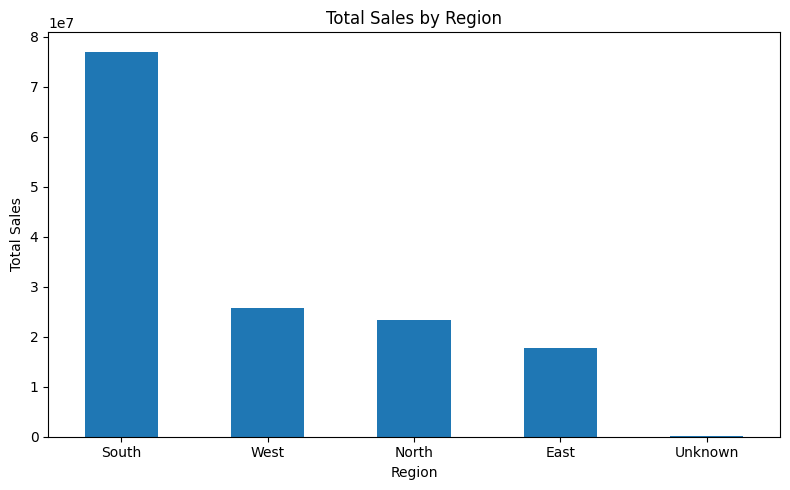

Insight: South generated the highest total sales of 77,069,287.50.


<Figure size 640x480 with 0 Axes>

In [62]:
# ============================================================
# MODULE 5: VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# USE MERGED DATA
# ============================================================

# merged_df was created in Module 3.
# It contains both Orders and Customers information.

# PREPARE DATA


# Make sure OrderDate is a datetime column
merged_df["OrderDate"] = pd.to_datetime(
    merged_df["OrderDate"],
    errors="coerce"
)

df = merged_df.copy()


# 1. REGION COMPARISON


region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Save directly in current directory
plt.savefig("module5_region_comparison.png", dpi=300)

# REAL FIGURE / INSIGHT

highest_region = region_sales.idxmax()
highest_region_sales = region_sales.max()

print(
    f"Insight: {highest_region} generated the highest total sales "
    f"of {highest_region_sales:,.2f}."
)


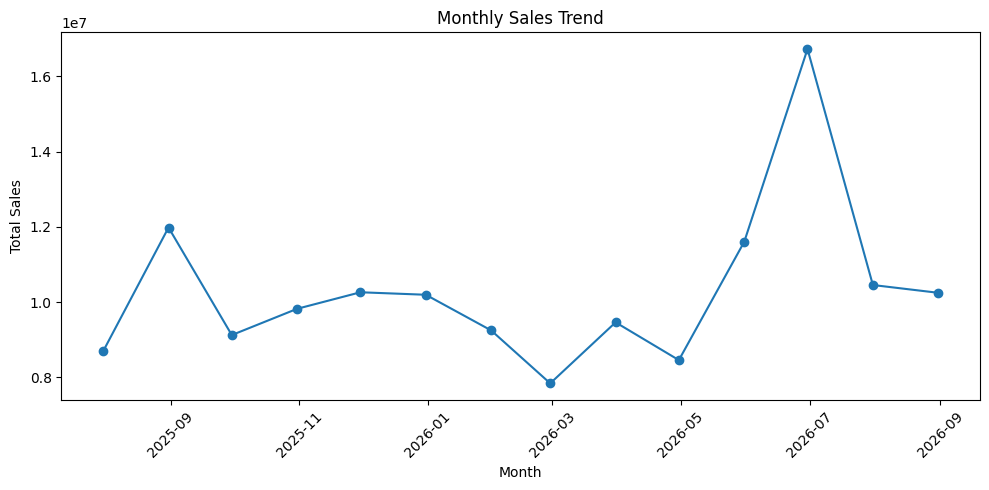

Insight: The highest monthly sales were 16,729,125.00 in June 2026.


In [63]:
# 2. TREND OVER TIME - MONTHLY SALES


monthly_sales = (
    merged_df
    .set_index("OrderDate")
    .resample("ME")["Sales"]
    .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

# Save directly in current directory
plt.savefig("module5_sales_trend.png", dpi=300)

plt.show()


# REAL FIGURE / INSIGHT
highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

print(
    f"Insight: The highest monthly sales were "
    f"{highest_month_sales:,.2f} in {highest_month.strftime('%B %Y')}."
)


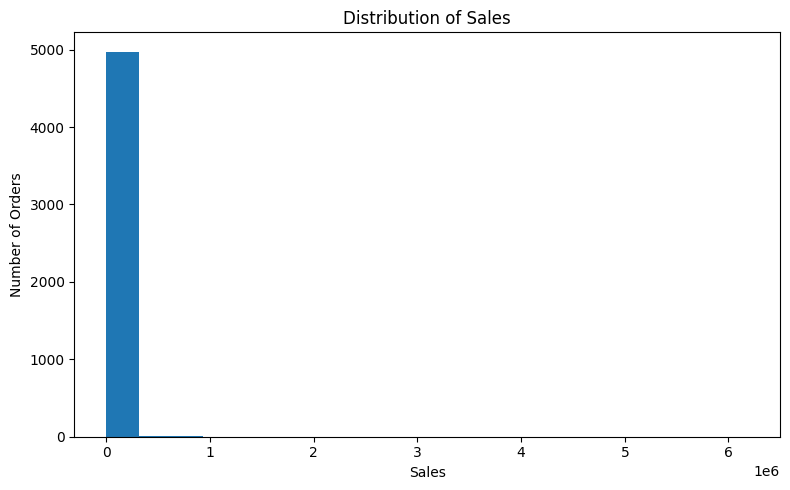

Insight: Mean Sales was 28,888.67, compared with a median of 10,800.00, indicating that high-value orders influence the average.


In [64]:
# 3. DISTRIBUTION - SALES


plt.figure(figsize=(8, 5))

plt.hist(
    merged_df["Sales"].dropna(),
    bins=20
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")

plt.tight_layout()

# Save directly in current directory
plt.savefig("module5_sales_distribution.png", dpi=300)

plt.show()


# REAL FIGURE / INSIGHT
sales_median = merged_df["Sales"].median()
sales_mean = merged_df["Sales"].mean()

print(
    f"Insight: Mean Sales was {sales_mean:,.2f}, compared with "
    f"a median of {sales_median:,.2f}, indicating that "
    f"high-value orders influence the average."
)


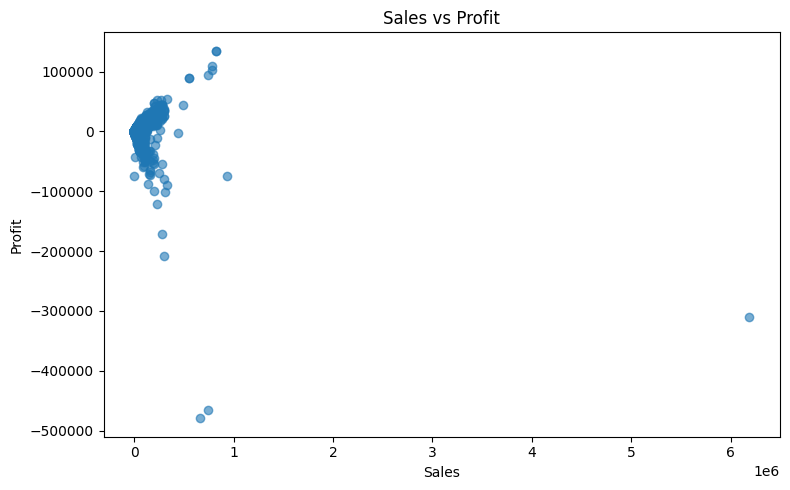

Insight: Sales and Profit have a correlation of -0.21, showing a negative relationship.


In [65]:
# 4. RELATIONSHIP BETWEEN TWO VARIABLES
#    SALES VS PROFIT

plt.figure(figsize=(8, 5))

plt.scatter(
    merged_df["Sales"],
    merged_df["Profit"],
    alpha=0.6
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()

# Save directly in current directory
plt.savefig("module5_sales_vs_profit.png", dpi=300)

plt.show()


# REAL FIGURE / INSIGHT
sales_profit_corr = merged_df[
    ["Sales", "Profit"]
].corr().loc["Sales", "Profit"]

print(
    f"Insight: Sales and Profit have a correlation of "
    f"{sales_profit_corr:.2f}, showing a "
    f"{'positive' if sales_profit_corr > 0 else 'negative'} relationship."
)


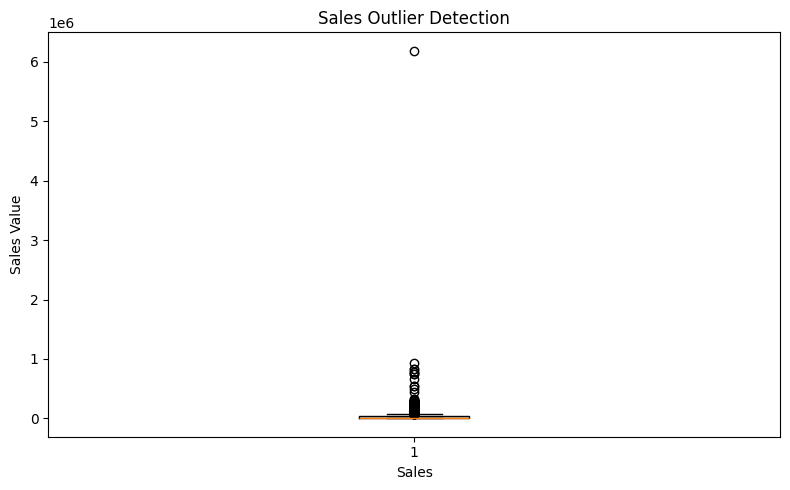

Insight: 393 orders were identified as Sales outliers using the IQR method, with an upper outlier boundary of 76,950.00.


In [66]:
# 5. OUTLIER VIEW - SALES
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    merged_df["Sales"].dropna()
)

plt.title("Sales Outlier Detection")
plt.xlabel("Sales")
plt.ylabel("Sales Value")

plt.tight_layout()

# Save directly in current directory
plt.savefig("module5_sales_outliers.png", dpi=300)

plt.show()


# Calculate IQR
Q1 = merged_df["Sales"].quantile(0.25)
Q3 = merged_df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = merged_df[
    (merged_df["Sales"] < lower_bound) |
    (merged_df["Sales"] > upper_bound)
]

print(
    f"Insight: {len(sales_outliers)} orders were identified "
    f"as Sales outliers using the IQR method, with an "
    f"upper outlier boundary of {upper_bound:,.2f}."
)


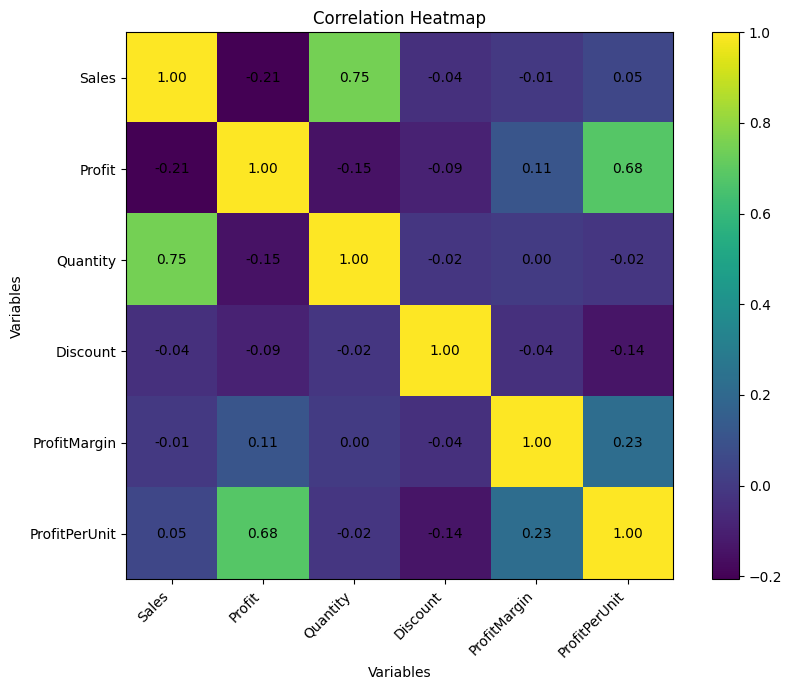


========== CORRELATION INSIGHTS ==========
Insight: Profit and ProfitPerUnit have a positive correlation of 0.68; higher Profit tends to be associated with higher ProfitPerUnit.
Insight: Quantity and Sales have a positive correlation of 0.75; higher Quantity tends to be associated with higher Sales.

========== MODULE 5 COMPLETED ==========
6 visualization files were saved directly in the current directory.


In [67]:
# 6. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "Sales",
    "Profit",
    "Quantity",
    "Discount",
    "ProfitMargin",
    "ProfitPerUnit"
]

correlation_matrix = merged_df[
    numeric_columns
].corr()


plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Display correlation values
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):

        value = correlation_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap")
plt.xlabel("Variables")
plt.ylabel("Variables")

plt.tight_layout()

# Save directly in current directory
plt.savefig("module5_correlation_heatmap.png", dpi=300)

plt.show()


# ============================================================
# CORRELATION INSIGHTS
# ============================================================

print("\n========== CORRELATION INSIGHTS ==========")

for column1 in correlation_matrix.columns:

    for column2 in correlation_matrix.columns:

        if column1 < column2:

            correlation = correlation_matrix.loc[
                column1,
                column2
            ]

            if correlation > 0.3:

                print(
                    f"Insight: {column1} and {column2} have a "
                    f"positive correlation of {correlation:.2f}; "
                    f"higher {column1} tends to be associated "
                    f"with higher {column2}."
                )

            elif correlation < -0.3:

                print(
                    f"Insight: {column1} and {column2} have a "
                    f"negative correlation of {correlation:.2f}; "
                    f"higher {column1} tends to be associated "
                    f"with lower {column2}."
                )


print("\n========== MODULE 5 COMPLETED ==========")

print("6 visualization files were saved directly in the current directory.")

In [68]:
#MODULE 6: EXCEL REPORTING
#Clean data → Save cleaned CSV → Read cleaned CSV → Create Excel report

#1. Save the cleaned data as CSV


# Export final cleaned and merged data

merged_df.to_excel(
    "Module6_Excel_Report.xlsx",
    sheet_name="Capstone2",
    index=False
)

print("Capstone2 data exported successfully.")

Capstone2 data exported successfully.


In [69]:


# MODULE 9: CUSTOMER SEGMENTATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



# 1. BUILD CUSTOMER-LEVEL FEATURES


customer_features = merged_df.groupby("CustomerID").agg(
    TotalSales=("Sales", "sum"),
    OrderCount=("OrderID", "count"),
    AverageOrderValue=("Sales", "mean")
).reset_index()

print("Customer-level features:")
print(customer_features.head())

print("\nNumber of customers:", len(customer_features))

Customer-level features:
  CustomerID  TotalSales  OrderCount  AverageOrderValue
0   CUST0002     56710.0           6        9451.666667
1   CUST0003    225305.0           9       25033.888889
2   CUST0004     44825.0           4       11206.250000
3   CUST0005     63680.0           4       15920.000000
4   CUST0006     43780.0           3       14593.333333

Number of customers: 596


In [70]:
#2. Check for missing values
# ------------------------------------------------------------
# 2. CHECK CUSTOMER FEATURES


print("\nMissing values:")
print(customer_features.isnull().sum())

print("\nSummary statistics:")
print(customer_features.describe())


Missing values:
CustomerID           0
TotalSales           0
OrderCount           0
AverageOrderValue    0
dtype: int64

Summary statistics:
         TotalSales  OrderCount  AverageOrderValue
count  5.960000e+02  596.000000         596.000000
mean   2.418699e+05    8.372483       28240.466654
std    3.338761e+05    4.678093       26172.455730
min    5.055000e+03    1.000000        1772.500000
25%    9.180750e+04    5.000000       15058.571429
50%    1.757450e+05    7.000000       22361.732143
75%    3.039394e+05   11.000000       33002.291667
max    6.572975e+06   24.000000      410810.937500


In [71]:
# 3. SCALE FEATURES
# ------------------------------------------------------------

features = [
    "TotalSales",
    "OrderCount",
    "AverageOrderValue"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    customer_features[features]
)

print("\nFeatures scaled successfully.")

#Without scaling, K-Means could give too much influence to TotalSales.

#StandardScaler() puts the variables on a comparable scale.


Features scaled successfully.


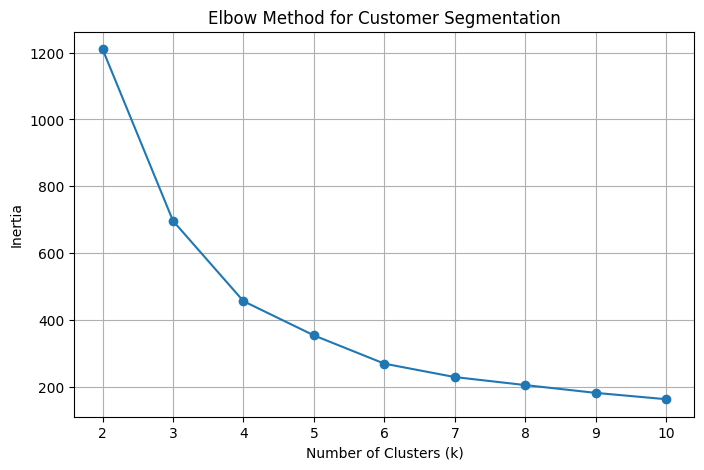

In [72]:
# 4. ELBOW METHOD
# ------------------------------------------------------------

inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


# Plot Elbow Method

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Customer Segmentation")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)

plt.savefig(
    "module9_elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
#5. Choose K and run K-Means

# 5. RUN K-MEANS


optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_features["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nK-Means clustering completed.")

print("\nCluster counts:")
print(customer_features["Cluster"].value_counts().sort_index())

#JUSTIFY
#I selected k = 4 because the inertia decreases substantially from k = 2 to k = 4 and then begins to flatten.
#Therefore, four clusters provide a reasonable balance between reducing within-cluster variation and avoiding unnecessary complexity.

# 6. CLUSTER PROFILE
# Understand the clusters calculate the average behavior of each cluster.

cluster_profile = customer_features.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    AverageTotalSales=("TotalSales", "mean"),
    AverageOrderCount=("OrderCount", "mean"),
    AverageOrderValue=("AverageOrderValue", "mean")
).reset_index()

print("\nCluster Profile:")
print(cluster_profile)


K-Means clustering completed.

Cluster counts:
Cluster
0    374
1    153
2     68
3      1
Name: count, dtype: int64

Cluster Profile:
   Cluster  Customers  AverageTotalSales  AverageOrderCount  AverageOrderValue
0        0        374       1.213803e+05           5.927807       20395.710053
1        1        153       3.781813e+05          14.921569       25270.990429
2        2         68       5.047574e+05           6.970588       72441.913127
3        3          1       6.572975e+06          16.000000      410810.937500


In [76]:
# 7. NAME CLUSTERS


cluster_names = {
    0: "Low-Engagement Customers",
    1: "Frequent Moderate Spenders",
    2: "Premium Occasional Spenders",
    3: "Exceptional VIP Customer"
}
customer_features["Segment"] = (
    customer_features["Cluster"]
    .map(cluster_names)
)

print("\nCustomer Segments:")
print(
    customer_features[
        ["CustomerID", "TotalSales", "OrderCount",
         "AverageOrderValue", "Cluster", "Segment"]
    ].head()
)


Customer Segments:
  CustomerID  TotalSales  OrderCount  AverageOrderValue  Cluster  \
0   CUST0002     56710.0           6        9451.666667        0   
1   CUST0003    225305.0           9       25033.888889        0   
2   CUST0004     44825.0           4       11206.250000        0   
3   CUST0005     63680.0           4       15920.000000        0   
4   CUST0006     43780.0           3       14593.333333        0   

                    Segment  
0  Low-Engagement Customers  
1  Low-Engagement Customers  
2  Low-Engagement Customers  
3  Low-Engagement Customers  
4  Low-Engagement Customers  


In [79]:
#8. One recommendation per cluster

# 8. BUSINESS RECOMMENDATIONS


recommendations = {
    "Low-Engagement Customers":
        "Use targeted discounts and re-engagement campaigns to encourage repeat purchases.",

    "Frequent Moderate Spenders":
        "Use product bundles and cross-selling offers to increase their average order value.",

    "Premium Occasional Buyers":
        "Promote premium products and personalized offers to encourage more frequent purchases.",

    "Exceptional VIP Customer":
        "Provide exclusive VIP benefits and personalized relationship management to retain this exceptionally high-value customer."
}

customer_features["Recommendation"] = (
    customer_features["Segment"].map(recommendations)
)

print("\nFinal Customer Segmentation:")
print(
    customer_features[
        ["CustomerID", "TotalSales", "OrderCount",
         "AverageOrderValue", "Segment", "Recommendation"]
    ].head(10)
)


Final Customer Segmentation:
  CustomerID  TotalSales  OrderCount  AverageOrderValue  \
0   CUST0002     56710.0           6        9451.666667   
1   CUST0003    225305.0           9       25033.888889   
2   CUST0004     44825.0           4       11206.250000   
3   CUST0005     63680.0           4       15920.000000   
4   CUST0006     43780.0           3       14593.333333   
5   CUST0007    777815.0          21       37038.809524   
6   CUST0008     19905.0           5        3981.000000   
7   CUST0009     82990.0           7       11855.714286   
8   CUST0010      6345.0           2        3172.500000   
9   CUST0011     73890.0           4       18472.500000   

                      Segment  \
0    Low-Engagement Customers   
1    Low-Engagement Customers   
2    Low-Engagement Customers   
3    Low-Engagement Customers   
4    Low-Engagement Customers   
5  Frequent Moderate Spenders   
6    Low-Engagement Customers   
7    Low-Engagement Customers   
8    Low-Engagement Cus

In [90]:

# MODULE 10: KPI REPORTING
# ============================================================

print("\n========== MODULE 10: KPI REPORTING ==========")


# KPI 1: TOTAL REVENUE

total_revenue = merged_df["Sales"].sum()

print("\n1. Total Revenue:")
print(f"Total Revenue = {total_revenue:,.2f}")

# Business use:
# Used by Sales Managers and Management.
# Helps decide whether overall sales performance is meeting targets.


# KPI 2: AVERAGE ORDER VALUE
# ------------------------------------------------------------

total_orders = merged_df["OrderID"].nunique()

average_order_value = total_revenue / total_orders

print("\n2. Average Order Value:")
print(f"AOV = {average_order_value:,.2f}")

# Business use:
# Used by Sales Managers.
# Helps decide whether upselling, cross-selling, and bundles
# are needed to increase the value of each order.

# KPI 3: REPEAT CUSTOMER RATE
# ------------------------------------------------------------

orders_per_customer = merged_df.groupby("CustomerID")["OrderID"].nunique()

total_customers = orders_per_customer.count()

repeat_customers = (orders_per_customer > 1).sum()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print("\n3. Repeat Customer Rate:")
print(f"Repeat Customer Rate = {repeat_customer_rate:.2f}%")

# Business use:
# Used by Marketing and CRM teams.
# Helps decide whether customer retention and loyalty campaigns
# need to be strengthened.

# KPI 4: REVENUE PER REGION
# ------------------------------------------------------------

revenue_by_region = (
    merged_df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n4. Revenue by Region:")
print(revenue_by_region)

# Business use:
# Used by Regional Sales Managers.
# Helps decide where to increase sales efforts and resources.

# KPI 5: PROFIT MARGIN
# ------------------------------------------------------------

total_profit = merged_df["Profit"].sum()

profit_margin = (
    total_profit / total_revenue
) * 100

print("\n6. Profit Margin:")
print(f"Profit Margin = {profit_margin:.2f}%")

# Business use:
# Used by Finance and Management.
# Helps decide whether pricing, discounts, and product mix
# are producing healthy profitability.

# KPI 6: REVENUE PER CATEGORY
# ------------------------------------------------------------

revenue_by_ProductCategory = (
    merged_df.groupby("ProductCategory")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n5. Revenue by ProductCategory:")
print(revenue_by_ProductCategory)

# Business use:
# Used by ProductCategory Managers.
# Helps decide which productcategories should receive
# more promotion, inventory, or sales attention.


========== MODULE 10: KPI REPORTING ==========

1. Total Revenue:
Total Revenue = 144,154,452.50

2. Average Order Value:
AOV = 28,888.67

3. Repeat Customer Rate:
Repeat Customer Rate = 98.83%

4. Revenue by Region:
Region
South      77069287.5
West       25837615.0
North      23327180.0
East       17772560.0
Unknown      147810.0
Name: Sales, dtype: float64

6. Profit Margin:
Profit Margin = 8.46%

5. Revenue by ProductCategory:
ProductCategory
Electronics        87694175.0
Furniture          36845400.0
Office Supplies    12982757.5
Accessories         6629060.0
Unknown                3060.0
Name: Sales, dtype: float64


In [87]:
print(merged_df.columns.tolist())

['OrderID', 'OrderDate', 'CustomerID', 'ProductCategory', 'Product', 'Quantity', 'Discount', 'Sales', 'Profit', 'PaymentMethod', 'OrderStatus', 'SalesPerUnit', 'ProfitMargin', 'LossFlag', 'CustomerName', 'Segment', 'Region', 'City', 'State', 'SignupDate', 'AgeGroup', 'ProfitPerUnit']
